### Packages

In [2]:
#pip install mplsoccer

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Sbopen, Pitch, VerticalPitch

### Event data documentation

https://mplsoccer.readthedocs.io/en/latest/gallery/statsbomb/plot_statsbomb_data.html#event-data

In [5]:
parser = Sbopen()

# Load dataframes containing event data from a specific match. 'df_event' stores the main events, and the other dfs provide context for them.
df_event, df_related, df_freeze, df_tactics = parser.event(7478)

print(f"\ndf_event: {df_event.columns}")
print(f"\ndf_related: {df_related.columns}")
print(f"\ndf_freeze: {df_freeze.columns}")
print(f"\ndf_tactics: {df_tactics.columns}")


df_event: Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'sub_type_id', 'sub_type_name',
       'body_part_id', 'body_part_name', 'x', 'y', 'under_pressure',
       'pass_switch', 'outcome_id', 'outcome_name',
       'ball_recovery_recovery_failure', 'counterpress', 'foul_won_defensive',
       'aerial_won', 'block_offensive', 'shot_statsbomb_xg', 'end_z',
       'technique_id', 'technique_name', 'goalkeeper_position_id',
       'goalkeeper_position_name', 'pass_assisted_shot_id', 'pass_goal_assist',
       'shot_key_pass_id', 'pass_cross', 'pass_back

In [6]:
help(Sbopen())

Help on Sbopen in module mplsoccer.soccer.statsbomb object:

class Sbopen(builtins.object)
 |  Sbopen(dataframe=True)
 |
 |  Class for loading data from the StatsBomb open-data.
 |  The data is available at: https://github.com/statsbomb/open-data under
 |  a non-commercial license.
 |
 |  Parameters
 |  ----------
 |  dataframe : bool, default True
 |      Whether to return dataframes (True) or flattened list of dictionaries (False)
 |      from the class methods.
 |
 |  Methods defined here:
 |
 |  __init__(self, dataframe=True)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  competition(self)
 |      StatsBomb competition open-data.
 |
 |      Returns
 |      -------
 |      competition
 |          A dataframe or a flattened list of dictionaries.
 |
 |      Examples
 |      --------
 |      >>> from mplsoccer import Sbopen
 |      >>> parser = Sbopen(dataframe=True)
 |      >>> competition = parser.competition()
 |
 |  event(self, match_id)
 |      Stats

### Finding match data

In [8]:
# Filter by competition
df_comp = parser.competition()

womens_euros = df_comp[df_comp['competition_name']=="UEFA Women's Euro"]
womens_euros

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
76,53,315,Europe,UEFA Women's Euro,female,False,True,2025,2026-04-27T22:02:42.690507,2026-04-27T22:03:28.087062,2026-04-27T22:03:28.087062,2026-04-27T22:02:42.690507
77,53,106,Europe,UEFA Women's Euro,female,False,True,2022,2026-05-05T03:03:04.199896,2026-05-05T03:05:32.480837,2026-05-05T03:05:32.480837,2026-05-05T03:03:04.199896


In [9]:
# Use competition_id and season_id to filter for match data

df_match = parser.match(competition_id=53, season_id=106)
display(df_match)
print(df_match.columns)

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3835320,2022-07-07,2022-07-07 19:00:00,4,1,available,available,2026-05-05 03:02:12.737593,2026-05-05 03:03:48.063607,1,...,10,Group Stage,4591,St. Mary's Stadium,68,England,965,Lina Lehtovaara,77,Finland
1,3835326,2022-07-10,2022-07-10 16:00:00,1,1,available,available,2026-05-05 03:01:47.218616,2026-05-05 03:03:15.908628,1,...,10,Group Stage,99,Joie Stadium,68,England,830,Tess Olofsson,220,Sweden
2,3835324,2022-07-09,2022-07-09 19:00:00,1,1,available,available,2026-05-05 03:00:47.821217,2026-05-05 03:01:16.555504,1,...,10,Group Stage,216,Bramall Lane,68,England,833,Cheryl Foster,249,Wales
3,3835336,2022-07-15,2022-07-15 19:00:00,1,0,available,available,2026-05-04 01:39:01.718048,2026-05-04 01:46:07.026825,3,...,10,Group Stage,203,The American Express Community Stadium,68,England,374,Kateryna Monzul,238,Ukraine
4,3835334,2022-07-14,2022-07-14 16:00:00,1,1,available,available,2026-05-04 01:36:48.260284,2026-05-04 01:39:37.641427,2,...,10,Group Stage,99,Joie Stadium,68,England,965,Lina Lehtovaara,77,Finland
5,3844386,2022-07-22,2022-07-22 19:00:00,1,0,available,available,2026-05-04 01:34:00.988774,2026-05-04 01:36:45.311000,4,...,11,Quarter-finals,4979,Leigh Sports Village Stadium,68,England,374,Kateryna Monzul,238,Ukraine
6,3835327,2022-07-11,2022-07-11 19:00:00,8,0,available,available,2026-05-04 01:33:31.461388,2026-05-04 01:36:42.564393,2,...,10,Group Stage,203,The American Express Community Stadium,68,England,990,Riem Hussein,85,Germany
7,3835330,2022-07-12,2022-07-12 19:00:00,2,0,available,available,2026-05-04 01:34:43.908715,2026-05-04 01:35:46.777713,2,...,10,Group Stage,116926,Gtech Community Stadium,68,England,128,Stéphanie Frappart,78,France
8,3844385,2022-07-21,2022-07-21 19:00:00,2,0,available,available,2026-05-04 01:33:03.018851,2026-05-04 01:33:30.718536,4,...,11,Quarter-finals,116926,Gtech Community Stadium,68,England,566,Rebecca Welch,68,England
9,3835339,2022-07-17,2022-07-17 16:00:00,1,4,available,available,2026-05-04 01:42:18.489412,2026-05-04 01:51:47.896173,3,...,10,Group Stage,216,Bramall Lane,68,England,811,Iuliana Elena Demetrescu,187,Romania


Index(['match_id', 'match_date', 'kick_off', 'home_score', 'away_score',
       'match_status', 'match_status_360', 'last_updated', 'last_updated_360',
       'match_week', 'competition_id', 'country_name', 'competition_name',
       'season_id', 'season_name', 'home_team_id', 'home_team_name',
       'home_team_gender', 'home_team_group', 'home_team_country_id',
       'home_team_country_name', 'home_team_managers_id',
       'home_team_managers_name', 'home_team_managers_nickname',
       'home_team_managers_dob', 'home_team_managers_country_id',
       'home_team_managers_country_name', 'away_team_id', 'away_team_name',
       'away_team_gender', 'away_team_group', 'away_team_country_id',
       'away_team_country_name', 'away_team_managers_id',
       'away_team_managers_name', 'away_team_managers_nickname',
       'away_team_managers_dob', 'away_team_managers_country_id',
       'away_team_managers_country_name', 'metadata_data_version',
       'metadata_shot_fidelity_version', 'm

In [10]:
df_match['home_team_name']

0          Norway Women's
1         Belgium Women's
2     Netherlands Women's
3         Austria Women's
4           Italy Women's
5          Sweden Women's
6         England Women's
7         Germany Women's
8         Germany Women's
9     Switzerland Women's
10         Sweden Women's
11        Germany Women's
12          Spain Women's
13        England Women's
14        England Women's
15        England Women's
16     Northern Ireland W
17       Portugal Women's
18         France Women's
19         France Women's
20        Iceland Women's
21        Denmark Women's
22            WNT Finland
23        Denmark Women's
24        Germany Women's
25    Netherlands Women's
26          Italy Women's
27         Sweden Women's
28        Austria Women's
29         France Women's
30        England Women's
Name: home_team_name, dtype: object

In [11]:
# England vs Sweden
swe_eng = df_match[
    (df_match['home_team_name'] == "England Women's") & (df_match['away_team_name'] == "Sweden Women's")
    ]

display(swe_eng)

print(f"Match id: {swe_eng['match_id']}")

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
15,3845506,2022-07-26,2022-07-26 21:00:00,4,0,available,available,2022-12-02 01:37:33.124516,2023-04-26 00:44:10.275394,5,...,15,Semi-finals,216,Bramall Lane,68,England,723,Esther Staubli,221,Switzerland


Match id: 15    3845506
Name: match_id, dtype: int64


### England vs Sweden

In [13]:
df, related, freeze, tactics = parser.event(3845506)
df.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'aerial_won', 'counterpress',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'shot_first_time', 'technique_id',
       'technique_name', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'out', 'off_camera', 'pass_cross', 'pass_switch', 'shot_one_on_one',
       'dribble_overrun', 'ball_recovery_rec

In [14]:
df['type_name'].value_counts()

type_name
Pass                 856
Ball Receipt         723
Carry                682
Pressure             304
Ball Recovery        106
Duel                  83
Dispossessed          37
Goal Keeper           37
Interception          36
Clearance             35
Block                 29
Shot                  28
Miscontrol            26
Dribble               23
Foul Committed        22
Foul Won              22
Dribbled Past         14
Substitution          10
Tactical Shift         5
Half Start             4
Half End               4
Shield                 3
Starting XI            2
50/50                  2
Injury Stoppage        1
Referee Ball-Drop      1
Name: count, dtype: int64

In [15]:
shots = df.loc[df['type_name']=='Shot']
shots.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_won_advantage,pass_cut_back,substitution_replacement_id,substitution_replacement_name,shot_open_goal,dribble_no_touch,foul_committed_card_id,foul_committed_card_name,dribble_nutmeg,block_offensive
25,763f23cf-485c-48a8-973b-903fc6d407d0,26,1,00:00:21.364000,0,21,3,0.286557,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,ebaf18d8-93b4-4b99-bca9-8999a0ded394,160,1,00:04:02.988000,4,2,9,0.658417,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,53f78998-0789-44dd-b163-950d76fab531,304,1,00:07:54.355000,7,54,19,1.092693,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
308,7ca6174f-6c4e-417c-914a-143f1d536d7d,309,1,00:08:39.842000,8,39,20,0.414881,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428,00823dd8-5b00-4a1b-b896-93dc7073163d,429,1,00:11:06.921000,11,6,25,1.080956,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
shots.columns

Index(['id', 'index', 'period', 'timestamp', 'minute', 'second', 'possession',
       'duration', 'match_id', 'type_id', 'type_name', 'possession_team_id',
       'possession_team_name', 'play_pattern_id', 'play_pattern_name',
       'team_id', 'team_name', 'tactics_formation', 'player_id', 'player_name',
       'position_id', 'position_name', 'pass_recipient_id',
       'pass_recipient_name', 'pass_length', 'pass_angle', 'pass_height_id',
       'pass_height_name', 'end_x', 'end_y', 'body_part_id', 'body_part_name',
       'sub_type_id', 'sub_type_name', 'x', 'y', 'under_pressure',
       'outcome_id', 'outcome_name', 'aerial_won', 'counterpress',
       'pass_assisted_shot_id', 'pass_shot_assist', 'shot_statsbomb_xg',
       'end_z', 'shot_key_pass_id', 'shot_first_time', 'technique_id',
       'technique_name', 'goalkeeper_position_id', 'goalkeeper_position_name',
       'out', 'off_camera', 'pass_cross', 'pass_switch', 'shot_one_on_one',
       'dribble_overrun', 'ball_recovery_rec

In [17]:
shots.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_won_advantage,pass_cut_back,substitution_replacement_id,substitution_replacement_name,shot_open_goal,dribble_no_touch,foul_committed_card_id,foul_committed_card_name,dribble_nutmeg,block_offensive
25,763f23cf-485c-48a8-973b-903fc6d407d0,26,1,00:00:21.364000,0,21,3,0.286557,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
159,ebaf18d8-93b4-4b99-bca9-8999a0ded394,160,1,00:04:02.988000,4,2,9,0.658417,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
303,53f78998-0789-44dd-b163-950d76fab531,304,1,00:07:54.355000,7,54,19,1.092693,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
308,7ca6174f-6c4e-417c-914a-143f1d536d7d,309,1,00:08:39.842000,8,39,20,0.414881,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
428,00823dd8-5b00-4a1b-b896-93dc7073163d,429,1,00:11:06.921000,11,6,25,1.080956,3845506,16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Successful
for i, shot in shots.iterrows():
    x = shot['x']
    print(x)

111.9
112.1
101.5
116.2
103.5
113.5
112.4
93.1
112.6
103.7
107.2
100.8
108.0
108.0
93.6
95.8
107.7
109.5
113.9
114.5
103.5
116.0
113.7
109.8
114.6
94.8
95.9
86.6


In [19]:
shots['team_name'].head()

25      Sweden Women's
159    England Women's
303     Sweden Women's
308     Sweden Women's
428    England Women's
Name: team_name, dtype: object

## Making the shot map
### Iterative way

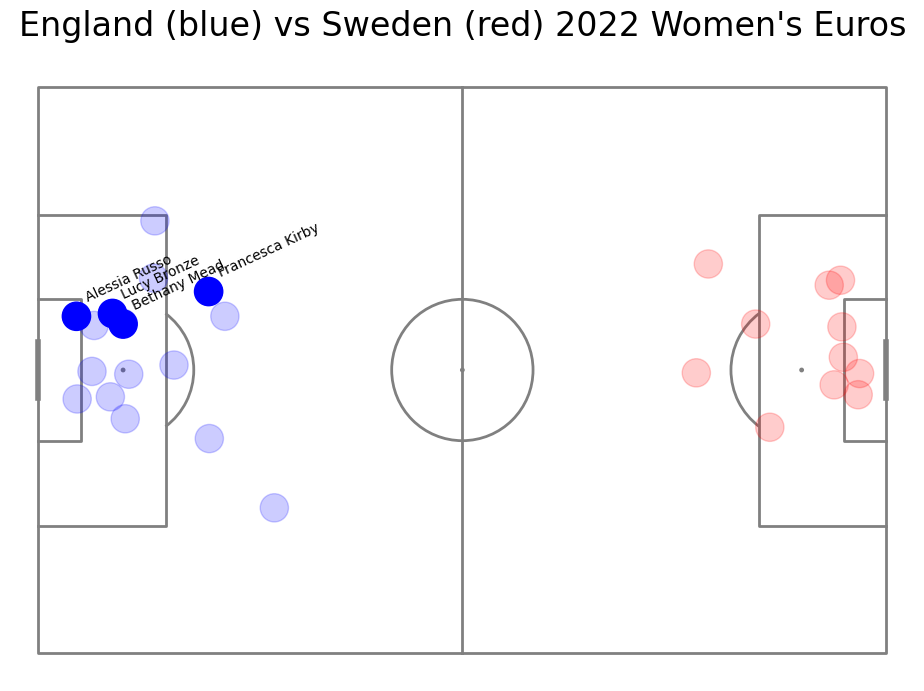

In [21]:
# Creating the pitch
pitch = Pitch(line_color='grey')
fig, ax = pitch.draw(figsize=(10, 7))

# Size of the pitch in yards
pitch_length_x = 120
pitch_width_y = 80

# Get shot data (coordinates, if it's a goal, what team made the shot)
for i, shot in shots.iterrows():
    x = shot['x']
    y = shot['y']
    goal = shot['outcome_name']=='Goal'
    team_name = shot['team_name']

    # Plot Sweden
    if (team_name=="Sweden Women's"):
        if goal:
            shotCircle=plt.Circle((x,y),radius=2,color="red")
            plt.text(x+1,y-2,shot['player_name']) 
        else:
            shotCircle=plt.Circle((x,y),radius=2,color="red")
            # Translucency
            shotCircle.set_alpha(0.2)
    # Plot England
    else:
        if goal:
            shotCircle=plt.Circle((pitch_length_x - x, pitch_width_y - y),radius=2,color="blue") 
            plt.text(pitch_length_x-x+1,pitch_width_y - y - 2 ,shot['player_name'], fontsize=10, rotation=25)
        else:
            shotCircle=plt.Circle((pitch_length_x - x,pitch_width_y - y),radius=2,color="blue")      
            shotCircle.set_alpha(0.2)
    ax.add_patch(shotCircle)

# Title
fig.suptitle("England (blue) vs Sweden (red) 2022 Women's Euros", fontsize = 24)     
fig.set_size_inches(10, 7)
plt.show()

## Plotting passes
### Get dataframe of passes

In [23]:
passes = df.loc[df['type_name']=='Pass']
passes.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,foul_won_advantage,pass_cut_back,substitution_replacement_id,substitution_replacement_name,shot_open_goal,dribble_no_touch,foul_committed_card_id,foul_committed_card_name,dribble_nutmeg,block_offensive
4,f3b23711-b9d0-4737-b0db-c05f0e8381a3,5,1,00:00:00.789000,0,0,2,1.071323,3845506,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,b2140123-8193-4513-b6b3-4b0ae308f534,8,1,00:00:02.796000,0,2,2,1.474217,3845506,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,b157508d-5808-4805-8783-dd19b176f2a1,12,1,00:00:05.773000,0,5,2,3.132030,3845506,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,2390de07-5b01-4413-9c99-3de2ecd3df7b,13,1,00:00:08.905000,0,8,2,1.686147,3845506,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,941680e6-a343-46ff-866a-5d2cd73c8412,21,1,00:00:16.093000,0,16,3,1.705326,3845506,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
print(passes['end_x'])
print(passes['end_y'])

4       53.0
7       27.9
11      87.0
12      48.2
20      87.6
        ... 
3074    75.7
3077    64.5
3080    95.1
3083    34.9
3091    35.2
Name: end_x, Length: 856, dtype: float64
4       37.1
7       55.0
11      55.0
12      22.1
20      18.7
        ... 
3074    57.7
3077    72.1
3080    71.4
3083     0.1
3091    19.2
Name: end_y, Length: 856, dtype: float64


### Plot every pass made by Caroline Seger (attacking left to right)

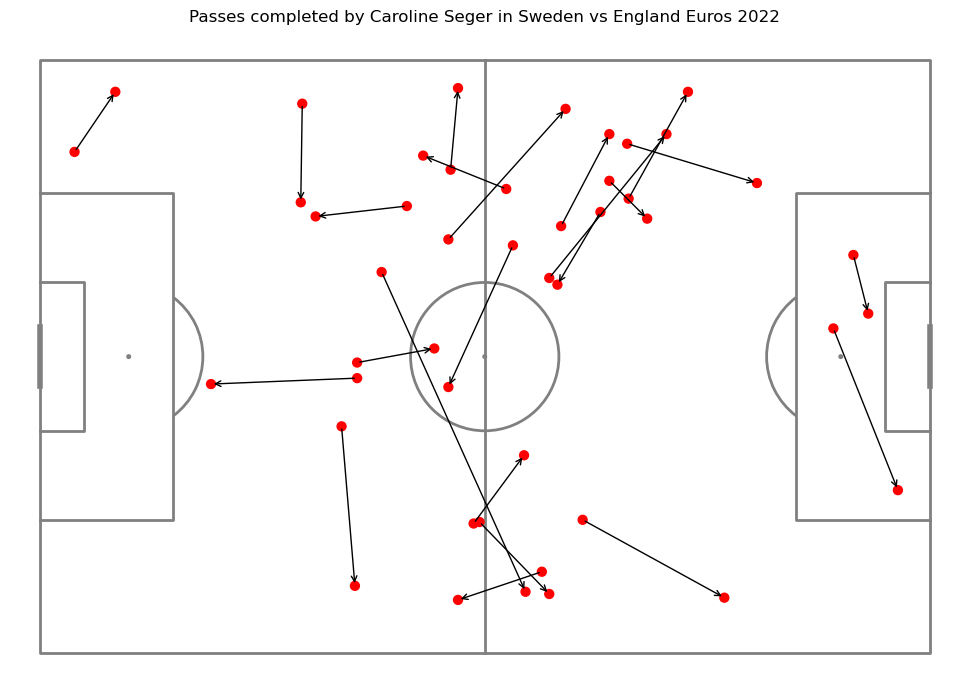

In [26]:
# Creating the pitch
pitch = Pitch(line_color='grey')
fig, ax = pitch.draw(figsize=(10, 7))

# Size of the pitch in yards
pitch_length_x = 120
pitch_width_y = 80

# Get passing data (coordinates for each pass)
for i, p in passes.iterrows():
    start_x = p['x']
    end_x = p['end_x']
    start_y = p['y']
    end_y = p['end_y']
    team_name = p['team_name']

    # Plot Seger's passes
    if team_name=="Sweden Women's":
        if p['player_name']=='Sara Caroline Seger':
            passCircle_start=plt.Circle((start_x,start_y),radius=0.6,color="red")
            # Arrows
            ax.annotate(text='', xy=(end_x, end_y), xytext=(start_x, start_y), arrowprops=dict(arrowstyle='->'))
            passCircle_end=plt.Circle((end_x,end_y),radius=0.6,color="red")
            ax.add_patch(passCircle_start)
            ax.add_patch(passCircle_end)

plt.title('Passes completed by Caroline Seger in Sweden vs England Euros 2022')
plt.show()